<a href="https://colab.research.google.com/github/Oksi193/Analyst_Customer/blob/main/User_Retention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# User Retention Analysis

## Impor Packages

In [7]:
import pandas as pd
import numpy as np
import datetime as dt
from scipy import stats

## Impor Data

In [22]:
# Baca datan
df = pd.read_csv('/Salinan Online Retail Data.csv')

# Tampilkan
df.head().style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.500000,12346.000000
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.250000,14590.000000
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.500000,12346.000000
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.850000,nan
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.750000,nan


In [9]:
# Informasi umum data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


## Data Preprocessing

In [10]:
df_clean = df.copy()

# 1. Mengkonversi kolom order_date menjadi datetime (Lebih aman dari astype)
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])

# 2. Membuat kolom year_month
df_clean['year_month'] = df_clean['order_date'].dt.to_period('M')

# 3. Menghapus semua baris tanpa customer_id
df_clean = df_clean[~df_clean['customer_id'].isna()]

# 4. Menghapus semua baris tanpa product_name
df_clean = df_clean[~df_clean['product_name'].isna()]

# 5. Membuat semua product_name berhuruf kecil
df_clean['product_name'] = df_clean['product_name'].str.lower()

# 6. Menghapus semua baris dengan product_code ATAU product_name test
# (Gunakan & agar data yang lolos adalah data yang bersih di code DAN bersih di name)
df_clean = df_clean[(~df_clean['product_code'].astype(str).str.lower().str.contains('test')) &
                    (~df_clean['product_name'].str.contains('test'))]

# 7. Membuat kolom order_status (Pastikan order_id di-cast ke string agar tidak error)
df_clean['order_status'] = np.where(df_clean['order_id'].astype(str).str[:1] == 'C', 'cancelled', 'delivered')

# 8. Mengubah nilai quantity yang negatif menjadi positif
df_clean['quantity'] = df_clean['quantity'].abs()

# 9. Menghapus baris dengan price bernilai negatif
df_clean = df_clean[df_clean['price'] > 0]

# 10. Membuat nilai amount
df_clean['amount'] = df_clean['quantity'] * df_clean['price']

# 11. Mengganti product_name dengan salah satu product_name-nya yang paling sering muncul
most_freq_product_name = df_clean.groupby(['product_code','product_name'], as_index=False).agg(order_cnt=('order_id','nunique')).sort_values(['product_code','order_cnt'], ascending=[True,False])
most_freq_product_name['rank'] = most_freq_product_name.groupby('product_code')['order_cnt'].rank(method='first', ascending=False)
most_freq_product_name = most_freq_product_name[most_freq_product_name['rank']==1].drop(columns=['order_cnt','rank'])

df_clean = df_clean.merge(most_freq_product_name.rename(columns={'product_name':'most_freq_product_name'}), how='left', on='product_code')
df_clean['product_name'] = df_clean['most_freq_product_name']
df_clean = df_clean.drop(columns='most_freq_product_name')

# 12. Mengkonversi customer_id menjadi string (Ubah ke int dulu untuk membuang desimal .0 bawaan NaN)
df_clean['customer_id'] = df_clean['customer_id'].astype(int).astype(str)

# 13. Menghapus outlier
df_clean = df_clean[(np.abs(stats.zscore(df_clean[['quantity','amount']])) < 3).all(axis=1)]

# 14. Reset index
df_clean = df_clean.reset_index(drop=True)

df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,year_month,order_status,amount
0,C493411,21539,red retrospot butter dish,1,2010-01-04 09:43:00,4.25,14590,2010-01,cancelled,4.25
1,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590,2010-01,delivered,91.80
2,493414,21533,retro spot large milk jug,12,2010-01-04 10:28:00,4.25,14590,2010-01,delivered,51.00
3,493414,37508,new england ceramic cake server,2,2010-01-04 10:28:00,2.55,14590,2010-01,delivered,5.10
4,493414,35001G,hand open shape gold,2,2010-01-04 10:28:00,4.25,14590,2010-01,delivered,8.50
...,...,...,...,...,...,...,...,...,...,...
358464,539988,84380,set of 3 butterfly cookie cutters,1,2010-12-23 16:06:00,1.25,18116,2010-12,delivered,1.25
358465,539988,84849D,hot baths soap holder,1,2010-12-23 16:06:00,1.69,18116,2010-12,delivered,1.69
358466,539988,84849B,fairy soap soap holder,1,2010-12-23 16:06:00,1.69,18116,2010-12,delivered,1.69
358467,539988,22854,cream sweetheart egg holder,2,2010-12-23 16:06:00,4.95,18116,2010-12,delivered,9.90


In [11]:
# Mengcheck hasil clening data
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358469 entries, 0 to 358468
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      358469 non-null  object        
 1   product_code  358469 non-null  object        
 2   product_name  358469 non-null  object        
 3   quantity      358469 non-null  int64         
 4   order_date    358469 non-null  datetime64[ns]
 5   price         358469 non-null  float64       
 6   customer_id   358469 non-null  object        
 7   year_month    358469 non-null  period[M]     
 8   order_status  358469 non-null  object        
 9   amount        358469 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5), period[M](1)
memory usage: 27.3+ MB


## Membuat User Retention Cohort

### Agregat data transaksi ke bentuk summary total transaksi/order setiap pengguna setiap bulan

In [12]:
df_user_monthly = df_clean.groupby(['customer_id','year_month'], as_index=False).agg(order_cnt=('order_id','nunique'))
df_user_monthly

,customer_id,year_month,order_cnt
0,12346,2010-01,1
1,12346,2010-03,1
2,12346,2010-06,2
3,12346,2010-10,1
4,12608,2010-10,1
...,...,...,...
12039,18286,2010-06,1
12040,18286,2010-08,1
12041,18287,2010-05,1
12042,18287,2010-09,2


### Buat kolom sebagai cohort dari pengguna, misal cohort bulan pertama kali bertransaksi

In [13]:
df_user_monthly['cohort'] = df_user_monthly.groupby('customer_id')['year_month'].transform('min')
df_user_monthly

,customer_id,year_month,order_cnt,cohort
0,12346,2010-01,1,2010-01
1,12346,2010-03,1,2010-01
2,12346,2010-06,2,2010-01
3,12346,2010-10,1,2010-01
4,12608,2010-10,1,2010-10
...,...,...,...,...
12039,18286,2010-06,1,2010-06
12040,18286,2010-08,1,2010-06
12041,18287,2010-05,1,2010-05
12042,18287,2010-09,2,2010-05


### Hitung jarak bulan antara bulan transaksi dengan bulan pertama kali transaksi dan jumlahkan dengan 1 agar jarak bulan 0 menjadi 1 yang berarti bulan pertama, dst.

In [14]:
from operator import attrgetter

df_user_monthly['period_num'] = (df_user_monthly['year_month'] - df_user_monthly['cohort']).apply(attrgetter('n')) + 1
df_user_monthly

,customer_id,year_month,order_cnt,cohort,period_num
0,12346,2010-01,1,2010-01,1
1,12346,2010-03,1,2010-01,3
2,12346,2010-06,2,2010-01,6
3,12346,2010-10,1,2010-01,10
4,12608,2010-10,1,2010-10,1
...,...,...,...,...,...
12039,18286,2010-06,1,2010-06,1
12040,18286,2010-08,1,2010-06,3
12041,18287,2010-05,1,2010-05,1
12042,18287,2010-09,2,2010-05,5


### Tabel pivot dengan index berupa cohort, kolom berupa jarak bulan, dan nilainya adalah banyaknya pengguna unik (count unique dari ID pengguna)

In [15]:
df_cohort_pivot = pd.pivot_table(df_user_monthly, index='cohort', columns='period_num', values='customer_id', aggfunc=pd.Series.nunique)
df_cohort_pivot

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,713.0,280.0,334.0,313.0,305.0,304.0,293.0,268.0,285.0,319.0,335.0,249.0
2010-02,461.0,154.0,128.0,161.0,152.0,121.0,119.0,159.0,153.0,166.0,100.0,NaN
2010-03,528.0,146.0,158.0,145.0,140.0,123.0,149.0,186.0,193.0,96.0,NaN,NaN
2010-04,326.0,82.0,75.0,63.0,69.0,79.0,98.0,101.0,50.0,NaN,NaN,NaN
2010-05,274.0,55.0,50.0,52.0,52.0,72.0,67.0,43.0,NaN,NaN,NaN,NaN
2010-06,266.0,53.0,56.0,60.0,65.0,85.0,39.0,NaN,NaN,NaN,NaN,NaN
2010-07,179.0,38.0,37.0,52.0,53.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,160.0,35.0,50.0,48.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,227.0,64.0,60.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Hitung banyaknya pengguna di masing-masing cohort (pengguna yang pertama kali transaksi di bulan tersebut) dan bagi semua nilai di tabel pivot tadi dengan nilai tersebut sebagai retention rate

In [16]:
cohort_size = df_cohort_pivot.iloc[:, 0]
cohort_size

,1
cohort,
2010-01,713.0
2010-02,461.0
2010-03,528.0
2010-04,326.0
2010-05,274.0
2010-06,266.0
2010-07,179.0
2010-08,160.0
2010-09,227.0


In [17]:
df_retention_cohort = df_cohort_pivot.divide(cohort_size, axis=0)
df_retention_cohort

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,1.0,0.392707,0.468443,0.438990,0.427770,0.426367,0.410940,0.375877,0.399719,0.447405,0.469846,0.349229
2010-02,1.0,0.334056,0.277657,0.349241,0.329718,0.262473,0.258134,0.344902,0.331887,0.360087,0.216920,NaN
2010-03,1.0,0.276515,0.299242,0.274621,0.265152,0.232955,0.282197,0.352273,0.365530,0.181818,NaN,NaN
2010-04,1.0,0.251534,0.230061,0.193252,0.211656,0.242331,0.300613,0.309816,0.153374,NaN,NaN,NaN
2010-05,1.0,0.200730,0.182482,0.189781,0.189781,0.262774,0.244526,0.156934,NaN,NaN,NaN,NaN
2010-06,1.0,0.199248,0.210526,0.225564,0.244361,0.319549,0.146617,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.212291,0.206704,0.290503,0.296089,0.167598,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.218750,0.312500,0.300000,0.168750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.281938,0.264317,0.136564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualisasi User Retention Cohort

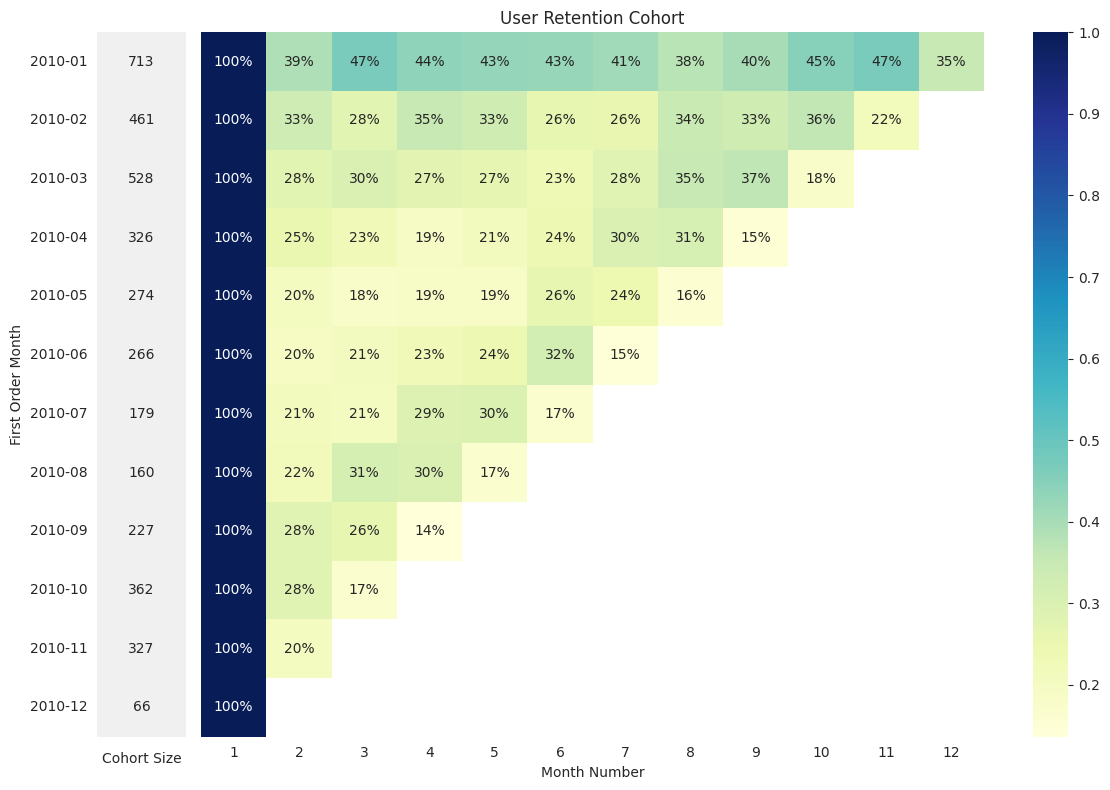

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

with sns.axes_style('white'):
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios':[1, 11]})

    # 1. USER RETENTION COHORT
    # Ganti 'YlGnBu' dengan skema warna lain yang Anda inginkan (lihat rekomendasi di bawah)
    sns.heatmap(df_retention_cohort, annot=True, fmt='.0%', cmap='YlGnBu', ax=ax[1])

    ax[1].set_title('User Retention Cohort')
    ax[1].set(xlabel='Month Number', ylabel='')

    # 2. COHORT SIZE
    df_cohort_size = pd.DataFrame(cohort_size)

    # Ganti 'white' dengan warna lain (misal: 'lightgray', '#F4F6F9', atau 'aliceblue')
    solid_cmap = mcolors.ListedColormap(['#F0F0F0'])
    sns.heatmap(df_cohort_size, annot=True, cbar=False, fmt='g', cmap=solid_cmap, ax=ax[0])

    ax[0].tick_params(bottom=False)
    ax[0].set(xlabel='Cohort Size', ylabel='First Order Month', xticklabels=[])

    fig.tight_layout()

- Cohort Tertinggi

Cohort Januari 2010 Tidak hanya memiliki jumlah pengguna baru terbanyak (713 user) juga memiliki tingkat loyalitas yang luar biasa. Retensi mereka stabil di angka 35% hingga 47% bahkan sampai bulan ke-11 dan ke-12. Ini sangat tinggi dibandingkan bulan-bulan lainnya.

- Penurunan Pengguna Baru

Jumlah akuisisi pengguna baru trennya terus menurun dari 713 di Januari, dengan selisih ratusan di pertengahan tahun, dan anjlok drastis ke hanya 66 pengguna di bulan Desember.

- Lonjakan di Bulan Tertentu

Pada Cohort 2010-06, di bulan ke-6 (sekitar bulan November kalender) retensinya melonjak ke 32%. Pada Cohort 2010-08, di bulan ke-3 (sekitar bulan Oktober kalender) retensinya melonjak ke 31%. Ini biasanya mengindikasikan ada pengaruh promo besar-besaran, kampanye marketing, atau faktor musiman di bulan kalender tersebut yang berhasil "membangunkan" pelanggan lama.

## Kesimpulan

- Investigasi Januari 2010:

Cari tahu apa yang dilakukan perusahaan pada Januari 2010. Apakah ada produk khusus, promo, atau target audience yang berbeda? Kita harus menduplikasi kesuksesan strategi di bulan ini.

- Evaluasi Strategi Pertengahan Tahun:

Cari tahu mengapa pengguna yang mendaftar di bulan April-Juli cepat sekali pergi (retensi rendah). Apakah ada masalah pada user experience, produk, atau customer service di periode tersebut?